         date  amount category    description
1  2024-07-02    50.0  expense      Groceries
2  2024-07-03   150.0  expense      Utilities
4  2024-07-05    75.0  expense     Restaurant
5  2024-07-06   100.0  expense      Transport
7  2024-07-08    30.0  expense         Snacks
9  2024-07-10    90.0  expense  Entertainment
10 2024-07-11    60.0  expense         Coffee
11 2024-07-12   120.0  expense            Gas
12 2024-07-13    80.0  expense          Books
13 2024-07-14   150.0  expense       Clothing
15 2024-07-16    40.0  expense     Stationery
16 2024-07-17   180.0  expense      Utilities
18 2024-07-19    70.0  expense     Restaurant
19 2024-07-20   130.0  expense      Transport
21 2024-07-22    35.0  expense         Snacks
23 2024-07-24   100.0  expense  Entertainment
24 2024-07-25    55.0  expense         Coffee
25 2024-07-26   140.0  expense            Gas
26 2024-07-27    90.0  expense          Books
27 2024-07-28   170.0  expense       Clothing
29 2024-07-30    45.0  expense    

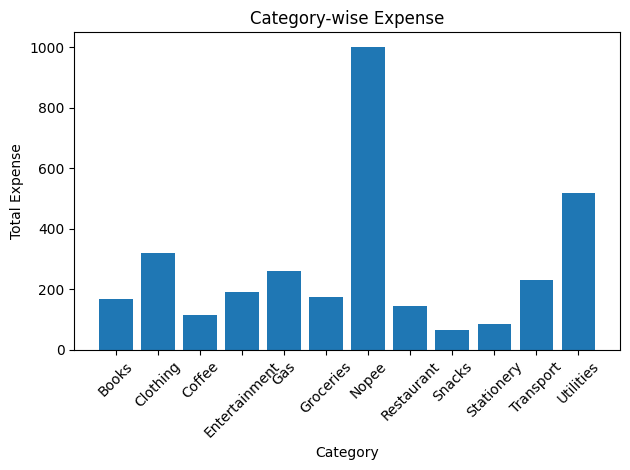

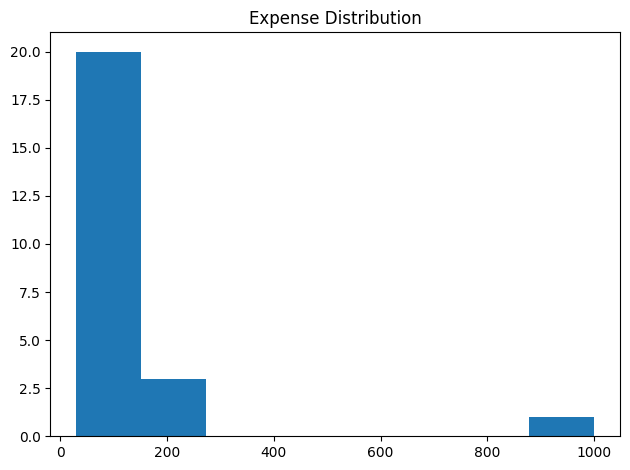

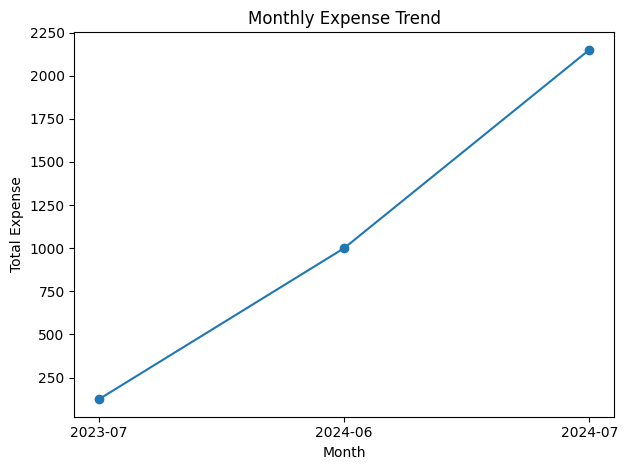

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("expense_data.csv")
df["date"] = pd.to_datetime(df["date"], dayfirst=True)

df["category"] = df["category"].str.strip().str.lower()
df["description"] = df["description"].str.strip()

expense_df = df[df["category"] == "expense"].copy()
print(expense_df)

total_expense = expense_df["amount"].sum()
print("\nTotal Expenses:", total_expense)

daily_expense = expense_df.groupby("date")["amount"].sum()
average_daily = daily_expense.mean()
print("\nAverage Daily Expense:", average_daily)

total = expense_df.groupby("description")["amount"].sum()

print("\nCategory-wise Total:", total)

if not total.empty:
    highest = total.idxmax()
    print("\nHighest Spending Category:", highest)
    print("Amount:", total.max())
else:
    print("No expense data found.")

plt.figure()
plt.bar(total.index, total.values)
plt.xticks(rotation=45)
plt.xlabel("Category")
plt.ylabel("Total Expense")
plt.title("Category-wise Expense")
plt.tight_layout()
plt.show()

plt.figure()
plt.hist(expense_df["amount"], bins=8)
plt.title("Expense Distribution")
plt.tight_layout()
plt.show()

expense_df["month"] = expense_df["date"].dt.to_period("M")
monthly_expense = expense_df.groupby("month")["amount"].sum()

plt.figure()
plt.plot(monthly_expense.index.astype(str), monthly_expense.values, marker="o")
plt.xlabel("Month")
plt.ylabel("Total Expense")
plt.title("Monthly Expense Trend")
plt.tight_layout()
plt.show()